In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import cv2
import albumentations as A
from PIL import Image
from tqdm import tqdm

source_root = '/content/drive/MyDrive/colon'
destination_root = '/content/drive/MyDrive/colon_augmented_png_v9'
os.makedirs(destination_root, exist_ok=True)

# Gentle and uniform augmentations for non-ulcer classes
balanced_transform = A.Compose([
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.04, contrast_limit=0.04, p=0.5),
        A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.5),
        A.Equalize(p=0.5),
    ], p=0.5),

    A.Rotate(limit=3, p=0.3),
    A.GaussianBlur(blur_limit=(1, 2), p=0.1),
    A.GaussNoise(var_limit=(3.0, 7.0), p=0.1),
    A.RandomGamma(gamma_limit=(95, 105), p=0.2),

    A.Resize(224, 224)
])

# Updated: Slightly stronger augmentations for ulcerative colitis
ulcer_transform = A.Compose([
    A.OneOf([
        A.RandomBrightnessContrast(brightness_limit=0.025, contrast_limit=0.025, p=0.4),
        A.CLAHE(clip_limit=2.0, tile_grid_size=(8, 8), p=0.3),
        A.Equalize(p=0.3),
    ], p=0.5),

    A.Rotate(limit=2, p=0.2),
    A.GaussianBlur(blur_limit=(1, 1), p=0.08),  # smaller blur
    A.GaussNoise(var_limit=(2.0, 4.0), p=0.08),  # gentler noise
    A.RandomGamma(gamma_limit=(97, 103), p=0.15),

    A.Resize(224, 224)
])


for class_name in os.listdir(source_root):
    class_input_path = os.path.join(source_root, class_name)
    if not os.path.isdir(class_input_path):
        continue

    class_output_path = os.path.join(destination_root, class_name)
    os.makedirs(class_output_path, exist_ok=True)

    print(f"Processing class: {class_name}")

    for img_name in tqdm(os.listdir(class_input_path)):
        img_path = os.path.join(class_input_path, img_name)

        try:
            image = cv2.imread(img_path)
            image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

            # Apply class-specific transformation
            if class_name == '1_ulcerative_colitis':
                augmented = ulcer_transform(image=image)['image']
            else:
                augmented = balanced_transform(image=image)['image']

            save_name = os.path.splitext(img_name)[0] + '_aug.png'
            save_path = os.path.join(class_output_path, save_name)
            Image.fromarray(augmented).save(save_path)

        except Exception as e:
            print(f"Failed to process {img_name}: {e}")


<ipython-input-4-53b24a920708>:21: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(3.0, 7.0), p=0.1),
<ipython-input-4-53b24a920708>:37: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(2.0, 4.0), p=0.08),  # gentler noise


Processing class: 1_ulcerative_colitis


100%|██████████| 1500/1500 [01:08<00:00, 21.85it/s]


Processing class: 0_normal


100%|██████████| 1500/1500 [01:07<00:00, 22.28it/s]


Processing class: 2_polyps


100%|██████████| 1500/1500 [01:05<00:00, 23.03it/s]


Processing class: 3_esophagitis


100%|██████████| 1500/1500 [01:40<00:00, 15.00it/s]


In [ ]:
# full dataset
import os
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
from math import log10, sqrt
import pandas as pd

# Define dataset paths
original_dir = '/content/drive/MyDrive/colon'
augmented_dir = '/content/drive/MyDrive/colon_augmented_png_v9'

# Helper metric functions
def calculate_mse(img1, img2):
    return np.mean((img1 - img2) ** 2)

def calculate_psnr(img1, img2):
    mse_val = calculate_mse(img1, img2)
    if mse_val == 0:
        return 100.0  # Use 100 dB instead of infinity to indicate perfect match
    return 20 * log10(255.0 / sqrt(mse_val))

def calculate_rmse(mse_val):
    return sqrt(mse_val)

# Store metrics per class
metrics_per_class = []

# Loop through each class folder
for cls in sorted(os.listdir(original_dir)):
    orig_cls_path = os.path.join(original_dir, cls)
    aug_cls_path = os.path.join(augmented_dir, cls)

    ssim_scores = []
    psnr_scores = []
    mse_scores = []
    rmse_scores = []

    orig_images = sorted(os.listdir(orig_cls_path))
    aug_images = sorted(os.listdir(aug_cls_path))

    for orig_img, aug_img in zip(orig_images, aug_images):
        try:
            orig_path = os.path.join(orig_cls_path, orig_img)
            aug_path = os.path.join(aug_cls_path, aug_img)

            # Load and resize
            img1 = cv2.imread(orig_path)
            img2 = cv2.imread(aug_path)
            img1 = cv2.resize(img1, (224, 224))
            img2 = cv2.resize(img2, (224, 224))

            # SSIM (on grayscale)
            gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
            gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
            ssim_val, _ = ssim(gray1, gray2, full=True)

            # MSE, PSNR, RMSE (on color)
            mse_val = calculate_mse(img1.astype("float"), img2.astype("float"))
            psnr_val = calculate_psnr(img1.astype("float"), img2.astype("float"))
            rmse_val = calculate_rmse(mse_val)

            # Append metrics
            ssim_scores.append(ssim_val)
            psnr_scores.append(psnr_val)
            mse_scores.append(mse_val)
            rmse_scores.append(rmse_val)

        except Exception as e:
            print(f"❌ Error comparing {orig_img}: {e}")

    # Compute average for the class
    metrics_per_class.append({
        "Class": cls,
        "SSIM": np.mean(ssim_scores),
        "PSNR (dB)": np.mean(psnr_scores),
        "MSE": np.mean(mse_scores),
        "RMSE": np.mean(rmse_scores)
    })

# Create DataFrame
df_metrics = pd.DataFrame(metrics_per_class)

# Display neatly
print("✅ Image Quality Comparison Metrics by Class:\n")
print(df_metrics.to_string(index=False, float_format='%.4f'))

✅ Image Quality Comparison Metrics by Class:

               Class   SSIM  PSNR (dB)      MSE    RMSE
            0_normal 0.8114    42.2428 788.4633 19.6665
1_ulcerative_colitis 0.8398    48.8185 815.2535 17.3193
            2_polyps 0.7803    41.8059 898.1238 20.5550
       3_esophagitis 0.8004    42.4064 667.1121 17.6184


In [11]:
import cv2
import numpy as np
from skimage.metrics import structural_similarity as ssim
from math import log10, sqrt
import pandas as pd
import os

# Paths for originals and augmentations
original_dir = "/content/drive/MyDrive/CareNet /colon"
augmented_images = {
    "normal": "/content/drive/MyDrive/CareNet /colon_augmented_png_v9/0_normal/train_normal_ (578)_aug.png",
    "ulcerative_colitis": "/content/drive/MyDrive/CareNet /colon_augmented_png_v9/1_ulcerative_colitis/train_ulcer_ (188)_aug.png",
    "polyps": "/content/drive/MyDrive/CareNet /colon_augmented_png_v9/2_polyps/test_polyps_ (83)_aug.png",
    "esophagitis": "/content/drive/MyDrive/CareNet /colon_augmented_png_v9/3_esophagitis/test_esophagitis_ (60)_aug.png",
}

# Helper functions
def calculate_mse(img1, img2):
    return np.mean((img1 - img2) ** 2)

def calculate_psnr(img1, img2):
    mse_val = calculate_mse(img1, img2)
    if mse_val == 0:
        return 100.0
    return 20 * log10(255.0 / sqrt(mse_val))

def calculate_rmse(mse_val):
    return sqrt(mse_val)

# Store metrics
metrics = []

for cls, aug_path in augmented_images.items():
    if not os.path.exists(aug_path):
        print(f"❌ Augmented image not found: {aug_path}")
        continue

    # Find matching original (remove _aug from filename)
    base_name = os.path.basename(aug_path).replace("_aug.png", ".jpg").replace("_aug.png", ".png")
    orig_path = os.path.join(original_dir, cls.split("_")[0] + "_" + cls.split("_")[-1] if "_" in cls else cls, base_name)

    # If that guess doesn't work, try parent folder mapping
    if not os.path.exists(orig_path):
        orig_path = os.path.join(original_dir, f"{list(aug_path.split('/'))[-2]}", base_name)

    if not os.path.exists(orig_path):
        print(f"❌ Could not locate original for {aug_path}")
        continue

    # Load and resize
    img1 = cv2.imread(orig_path)
    img2 = cv2.imread(aug_path)
    img1 = cv2.resize(img1, (224, 224))
    img2 = cv2.resize(img2, (224, 224))

    # SSIM (grayscale)
    gray1 = cv2.cvtColor(img1, cv2.COLOR_BGR2GRAY)
    gray2 = cv2.cvtColor(img2, cv2.COLOR_BGR2GRAY)
    ssim_val, _ = ssim(gray1, gray2, full=True)

    # MSE, PSNR, RMSE
    mse_val = calculate_mse(img1.astype("float"), img2.astype("float"))
    psnr_val = calculate_psnr(img1.astype("float"), img2.astype("float"))
    rmse_val = calculate_rmse(mse_val)

    metrics.append({
        "Class": cls,
        "SSIM": ssim_val,
        "PSNR (dB)": psnr_val,
        "MSE": mse_val,
        "RMSE": rmse_val
    })

# Convert to DataFrame for pretty print
df_metrics = pd.DataFrame(metrics)
print("\n✅ Image Quality Metrics for Selected Images:\n")
print(df_metrics.to_string(index=False, float_format="%.4f"))



✅ Image Quality Metrics for Selected Images:

             Class   SSIM  PSNR (dB)      MSE    RMSE
            normal 0.8539    26.6586 140.3510 11.8470
ulcerative_colitis 0.8764    22.5579 360.8165 18.9952
            polyps 0.8036    24.0239 257.4489 16.0452
       esophagitis 0.8579    22.4581 369.2038 19.2147


/tmp/ipython-input-1033640851.py:32: UserWarning: Argument(s) 'always_apply' are not valid for transform Rotate
  lambda img: A.Rotate(
/tmp/ipython-input-1033640851.py:41: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  lambda img: A.GaussNoise(var_limit=(3.0, 7.0), p=1.0)(image=img)["image"]),


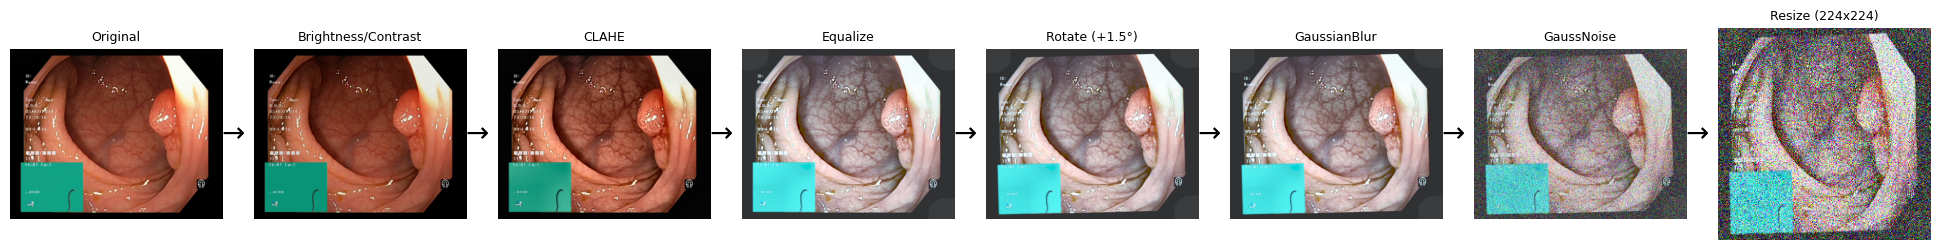

In [ ]:
import cv2
import albumentations as A
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch

# ---- path to image ----
img_path = "/content/drive/MyDrive/colon/2_polyps/val_polyps_ (492).jpg"

# load image (RGB)
image_bgr = cv2.imread(img_path)
if image_bgr is None:
    raise FileNotFoundError(f"Could not load image: {img_path}")
image = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)

# ---- rotation angle (degrees) ----
ROT_ANGLE_DEG = 1.5

# ---- sequential, cumulative steps ----
steps = [
    ("Original", lambda img: img),
    ("Brightness/Contrast",
     lambda img: A.RandomBrightnessContrast(
         brightness_limit=0.04, contrast_limit=0.04, p=1.0
     )(image=img)["image"]),
    ("CLAHE",
     lambda img: A.CLAHE(
         clip_limit=2.0, tile_grid_size=(8, 8), p=1.0
     )(image=img)["image"]),
    ("Equalize",
     lambda img: A.Equalize(p=1.0)(image=img)["image"]),
    ("Rotate (+1.5°)",
     lambda img: A.Rotate(
         limit=(ROT_ANGLE_DEG, ROT_ANGLE_DEG),
         interpolation=cv2.INTER_LINEAR,
         border_mode=cv2.BORDER_REFLECT_101,
         always_apply=True
     )(image=img)["image"]),
    ("GaussianBlur",
     lambda img: A.GaussianBlur(blur_limit=(1, 2), p=1.0)(image=img)["image"]),
    ("GaussNoise",
     lambda img: A.GaussNoise(var_limit=(3.0, 7.0), p=1.0)(image=img)["image"]),
    ("Resize (224x224)",
     lambda img: A.Resize(224, 224, p=1.0)(image=img)["image"]),
]

# ---- apply cumulatively ----
results = []
current = image
for name, fn in steps:
    current = fn(current)
    results.append((name, current))

# ---- plot with reduced gaps (unchanged layout) ----
fig_width = max(2.5 * len(results), 16)
fig, axes = plt.subplots(1, len(results), figsize=(fig_width, 5))

for i, (name, img) in enumerate(results):
    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(name, fontsize=9)

# Alternative approach using text arrows
for i in range(len(results) - 1):
    # Get positions of current and next axes
    bbox1 = axes[i].get_position()
    bbox2 = axes[i+1].get_position()

    # Calculate the center of the gap
    gap_center_x = (bbox1.x1 + bbox2.x0) / 2
    y_mid = (bbox1.y0 + bbox1.y1) / 2

    # Add a simple arrow using text
    axes[i].annotate('→',
                    xy=(1.05, 0.5),
                    xycoords='axes fraction',
                    fontsize=20,
                    ha='center',
                    va='center',
                    color='black')

plt.subplots_adjust(wspace=0.15, left=0.02, right=0.98, bottom=0.1, top=0.9)
plt.show()